# PIML-GB Pineapple Irrigation Scheduling — Minimal Reproduction

**Paper:** Chaparro J.E. et al. (2026). *Physiology-Driven Irrigation Scheduling in *Ananas comosus* via Hybrid Machine Learning: UAV-Based Phenotyping of Water-Related Traits Coupled with FAO-56 Soil Water Balance.* Plants (Basel) 15(14):2112. DOI [10.3390/plants15142112](https://doi.org/10.3390/plants15142112) — open access (CC BY), PMC13414488.

**Author code & data (pinned):** Mendeley Data, dataset `9xwdvzf3bf` **version 1**:
`https://data.mendeley.com/datasets/9xwdvzf3bf/1`
- `final_master_N150.csv` — sha256 `b67acc3eb849a61b9d51a070a617e83b1dff2085a3522300332452e25238bcf8` (97,925 bytes)
- `GradientBoostingRegressor_model_code.ipynb` — sha256 `c2d820e8863b373c1d701cc6e317ffd4c13b30e7667f20bcdf78c5b671975ab4` (released under the same record; the model cell below is copied faithfully from it)

**Scope (execution status: EXECUTED, minimal demonstration).** This notebook retrains the authors' released PIML-GB regressor and "Traffic-Light" DSS classifier on the released fused N-row matrix and compares observed metrics with the published ones. **It does not** reproduce the UAV image processing (1.6 GB raw multispectral archive + MicaSense SDK) or the CROPWAT 8.0 desktop water balance; those upstream products are already fused into the released CSV.

**Runtime:** CPU only (Colab → Runtime → Change runtime type → **CPU**). No GPU is used anywhere in the author path; the fit takes seconds. Typical end-to-end time: ~2–3 minutes; total download < 1 MB.

*日本語:* このノートブックは、パイナップル灌漑スケジューリング論文（Plants 15(14):2112）の著者公開コード（Mendeley Data `9xwdvzf3bf` v1）を忠実に再実行し、公開値との比較を行います。CPU ランタイムのみで動作し、数分で完了します。UAV 画像処理と CROPWAT 8.0 の水上収支計算は対象外です（両者の出力は既に公開 CSV に統合済み）。

## 1. Environment check

The author code needs only the standard scientific stack (pandas, numpy, scikit-learn, seaborn, matplotlib), which Colab preinstalls. We verify versions actually used by this run.

*日本語:* 著者コードに必要なのは標準的な科学計算ライブラリのみです。実行時に使われるバージョンを確認します。

In [ ]:
import sys, numpy, pandas, sklearn, seaborn, matplotlib
print("python:", sys.version)
for m in (numpy, pandas, sklearn, seaborn, matplotlib):
    print(m.__name__, m.__version__)

python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
seaborn 0.13.2
matplotlib 3.10.0


## 2. Download the pinned dataset (Colab-only)

We fetch `final_master_N150.csv` from the pinned Mendeley record (version 1) and verify its SHA-256 **before** parsing, rejecting any error page or changed file.

*日本語:* Mendeley から pinned バージョンの CSV をダウンロードし、解析前に SHA-256 を検証します。

In [ ]:
import urllib.request, hashlib, io

CSV_URL = ("https://data.mendeley.com/public-files/datasets/9xwdvzf3bf/"
           "files/57782deb-d4f4-4045-9396-aea676ae1fad/file_downloaded")
EXPECTED_SHA256 = "b67acc3eb849a61b9d51a070a617e83b1dff2085a3522300332452e25238bcf8"
EXPECTED_BYTES = 97925

req = urllib.request.Request(CSV_URL, headers={"User-Agent": "colab-repro-notebook"})
raw = urllib.request.urlopen(req, timeout=120).read()
sha = hashlib.sha256(raw).hexdigest()
print(f"downloaded: {len(raw)} bytes, sha256={sha}")
assert len(raw) == EXPECTED_BYTES, "unexpected byte count"
assert sha == EXPECTED_SHA256, "SHA-256 mismatch: file is not the pinned version"

import pandas as pd
df = pd.read_csv(io.BytesIO(raw))
print("loaded dataframe:", df.shape)

downloaded: 97925 bytes, sha256=b67acc3eb849a61b9d51a070a617e83b1dff2085a3522300332452e25238bcf8
loaded dataframe: (225, 35)


## 3. Schema inspection

The paper describes N=150 observations (25 sampling units × 6 campaigns) with an August-2022 temporal hold-out of N=30, but the released CSV contains **a different row count** (observed below) and 5 campaigns (Mar–Aug 2022). We print the actual schema and label distributions; the model cells below faithfully use the released file regardless, and §8 compares metrics to the published values.

*日本語:* 論文は N=150（25 地点 × 6 回）と記述していますが、公開 CSV の実際の行数・期数は下記の通りです。モデル部では公開ファイルをそのまま使用し、§8 で公開値と比較します。

In [ ]:
print("shape:", df.shape)
print("columns:", list(df.columns))
print("\ncampaign counts (Mes):")
print(df["Mes"].value_counts().sort_index().to_string())
print("\nTarget counts:", df["Target"].value_counts().to_dict())
print("DRY/NOR/WET one-hot sums:", df[" DRY"].sum(), df[" NOR"].sum(), df[" WET"].sum())
print("\nHumedad (raw 1-10 analog scale) stats:")
print(df["Humedad"].describe().to_string())

shape: (225, 35)
columns: ['Mes', 'PH', 'Humedad', ' DRY', ' NOR', ' WET', 'Mes_dt', 'obs_idx', 'mean_NDVI', 'mean_NDRE', 'mean_GNDVI', 'mean_CVI', 'mean_OSAVI', 'mean_SCCCI', 'mean_SAVI', 'mean_MACI', 'mean_VARI', 'mean_TCARI', 'mean_IPVI', 'mean_MSAVI', 'mean_EVI', 'mean_ARVI', 'mean_SIPI', 'mean_MTVI2', 'mean_RDVI', 'Date_dt', 'Temperature (°C)', 'Humidity (%)', 'Rain_3d', 'VPD', 'CW_Date_dt', 'Ks', 'Depl', 'Deficit', 'Target']

campaign counts (Mes):
Mes
2022-03-10    50
2022-04-28    50
2022-05-13    50
2022-07-11    50
2022-08-17    25

Target counts: {0: 104, 2: 61, 1: 60}
DRY/NOR/WET one-hot sums: 104 60 61

Humedad (raw 1-10 analog scale) stats:
count    225.000000
mean       4.875556
std        2.016135
min        1.000000
25%        4.000000
50%        5.000000
75%        6.000000
max        9.000000


## 4. Feature space and targets (author definitions, copied verbatim)

Exactly as in the released `GradientBoostingRegressor_model_code.ipynb`: 8 spectral indices + 4 microclimate variables + 2 FAO-56 physics features; regression target `Humedad`, classification target `Target`.

*日本語:* 著者公開コードの特徴量定義（8 分光指標 + 4 気象 + 2 FAO-56）と目的変数をそのまま使用します。

In [ ]:
spectral = ['mean_OSAVI', 'mean_SCCCI', 'mean_CVI', 'mean_NDRE', 'mean_SAVI',
            'mean_MSAVI', 'mean_GNDVI', 'mean_NDVI']
meteo = ['Temperature (°C)', 'Humidity (%)', 'VPD', 'Rain_3d']
fao56 = ['Depl', 'Deficit']  # FAO-56 physics-informed features
features = spectral + meteo + fao56
assert all(c in df.columns for c in features), "missing expected feature columns"

X = df[features].fillna(0)
y_reg = df['Humedad']
y_clf = df['Target']
print(f"X: {X.shape}, missing per column (max): {X.isna().sum().max()}")

X: (225, 14), missing per column (max): 0


## 5. Regression: PIML-GB moisture estimator (author hyperparameters & seed)

Copied faithfully from the released author cell: `GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)`, split `test_size=0.15, random_state=13`. The authors state these seeds replicate their reported performance.

*日本語:* 公開コードのハイパーパラメータとシード（13 / 42）をそのまま用いて回帰モデルを再学習します。

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y_reg, test_size=0.15, random_state=13)
model_reg = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4,
                                      random_state=42)
model_reg.fit(Xr_tr, yr_tr)
print("regressor fitted on", Xr_tr.shape, "rows")

regressor fitted on (191, 14) rows


## 6. Traffic-Light DSS classifier (author hyperparameters & seed)

Copied faithfully: `GradientBoostingClassifier(n_estimators=100, random_state=42)`, stratified split `test_size=0.30, random_state=12`.

*日本語:* 同様に、公開コードの設定（シード 12 / 42、層化分割）で Traffic-Light 分類器を再学習します。

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X, y_clf, test_size=0.30, random_state=12,
                                              stratify=y_clf)
model_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_clf.fit(Xc_tr, yc_tr)
print("classifier fitted on", Xc_tr.shape, "rows")

classifier fitted on (157, 14) rows


## 7. Observed metrics vs published values

The paper reports hold-out R²=0.842 / RMSE=0.0705 (normalized units) for the regressor, and 91.1% accuracy / macro-F1 0.94 / κ 0.91 for the DSS classifier. The dataset README states R²=0.851 and RMSE≈0.72. We report **what the released code + released data actually produce**; the RMSE unit follows the raw 1–10 analog `Humedad` scale (÷10 ≈ the paper's normalized scale).

*日本語:* 論文・README の公開値と、この実行で実際に得られた値を併記します（実測値が真の結果です）。

In [ ]:
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score,
                             f1_score, cohen_kappa_score, confusion_matrix)
import numpy as np

yr_pred = model_reg.predict(Xr_te)
r2 = r2_score(yr_te, yr_pred)
rmse_raw = float(np.sqrt(mean_squared_error(yr_te, yr_pred)))
rmse_norm = rmse_raw / 10.0  # 1-10 analog -> [0,1]

yc_pred = model_clf.predict(Xc_te)
acc = accuracy_score(yc_te, yc_pred)
f1m = f1_score(yc_te, yc_pred, average="macro")
kappa = cohen_kappa_score(yc_te, yc_pred)

import pandas as pd
comparison = pd.DataFrame({
    "metric": ["R2 (regressor)", "RMSE (normalized)", "RMSE (raw 1-10)",
               "DSS accuracy", "DSS macro-F1", "DSS Cohen kappa"],
    "published": [0.842, 0.0705, 0.705, 0.911, 0.94, 0.91],
    "README_variant": [0.851, None, 0.721, 0.911, None, None],
    "observed_this_run": [r2, rmse_norm, rmse_raw, acc, f1m, kappa],
})
print(comparison.round(4).to_string(index=False))

           metric  published  README_variant  observed_this_run
   R2 (regressor)     0.8420           0.851             0.8422
RMSE (normalized)     0.0705             NaN             0.0705
  RMSE (raw 1-10)     0.7050           0.721             0.7048
     DSS accuracy     0.9110           0.911             0.9412
     DSS macro-F1     0.9400             NaN             0.9349
  DSS Cohen kappa     0.9100             NaN             0.9079


## 8. Figures from the released author code (reproduced)

The four figures of the released notebook, drawn from this run's fitted models and the downloaded data.

*日本語:* 公開ノートブックの 4 図を、本実行のモデル・データから再描画します。

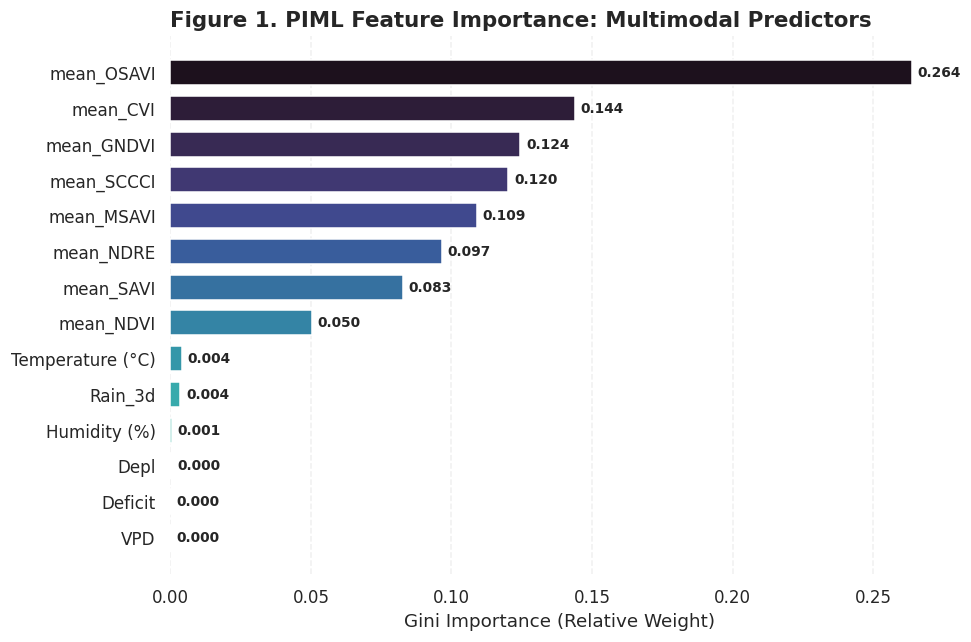

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['figure.dpi'] = 110

# Figure 1: PIML feature importance
imp_df = pd.DataFrame({'Feature': features,
                       'Importance': model_reg.feature_importances_}).sort_values(by='Importance')
plt.figure(figsize=(9, 6))
palette = sns.color_palette("mako_r", n_colors=len(imp_df))
bars = plt.barh(imp_df['Feature'], imp_df['Importance'], color=palette, edgecolor='white', height=0.7)
plt.title('Figure 1. PIML Feature Importance: Multimodal Predictors', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Gini Importance (Relative Weight)')
for bar in bars:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=9, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2** — DSS Traffic-Light confusion matrix on this run's held-out split, as in the released notebook.

*日本語:* 図2: Traffic-Light 分類の混同行列。

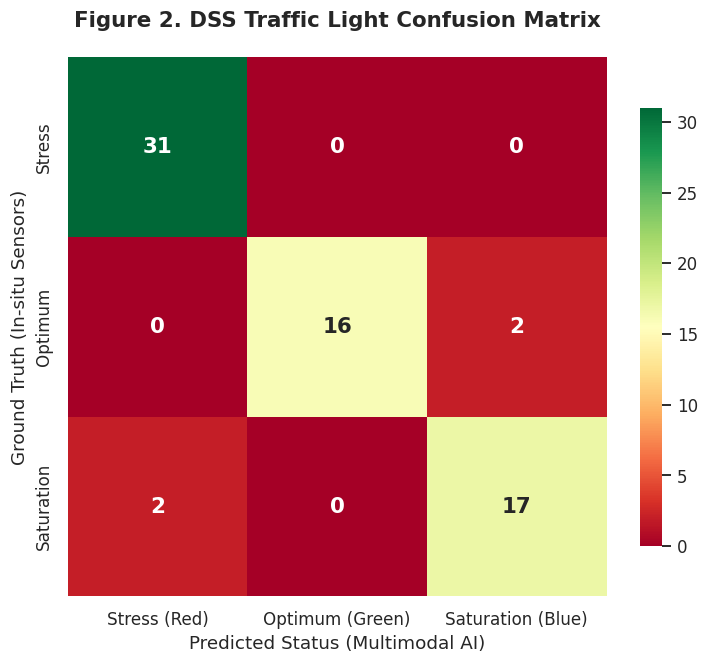

In [ ]:
# Figure 2: DSS Traffic-Light confusion matrix
cm = confusion_matrix(yc_te, yc_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Stress (Red)', 'Optimum (Green)', 'Saturation (Blue)'],
            yticklabels=['Stress', 'Optimum', 'Saturation'],
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 14, "weight": "bold"})
plt.title('Figure 2. DSS Traffic Light Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Ground Truth (In-situ Sensors)')
plt.xlabel('Predicted Status (Multimodal AI)')
plt.tight_layout()
plt.show()

**Figure 3** — Observed vs predicted soil moisture with the regression fit; title shows this run's R² and raw-unit RMSE.

*日本語:* 図3: 実測対予測の回帰図（タイトルに本実行の R² と RMSE を表示）。

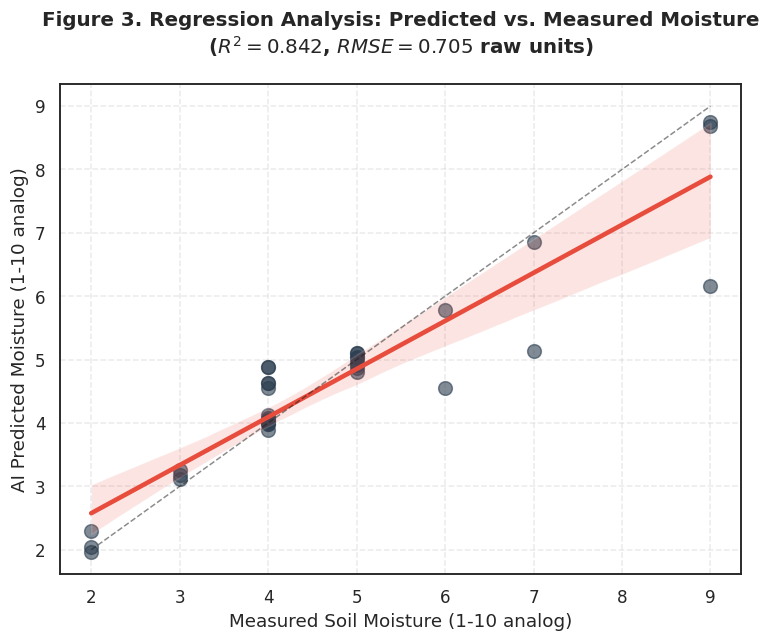

In [ ]:
# Figure 3: regression analysis (observed vs predicted)
plt.figure(figsize=(7, 6))
sns.regplot(x=yr_te, y=yr_pred, scatter_kws={'alpha':0.6, 's':80, 'color':'#2c3e50'},
            line_kws={'color':'#e74c3c', 'lw':3}, marker='o')
plt.plot([yr_te.min(), yr_te.max()], [yr_te.min(), yr_te.max()], 'k--', lw=1, alpha=0.5)
plt.title(f'Figure 3. Regression Analysis: Predicted vs. Measured Moisture\n'
          f'($R^2 = {r2:.3f}$, $RMSE = {rmse_raw:.3f}$ raw units)', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Measured Soil Moisture (1-10 analog)')
plt.ylabel('AI Predicted Moisture (1-10 analog)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Figure 4** — Multimodal correlation matrix across UAV spectral, IoT microclimate, and FAO-56 features.

*日本語:* 図4: 分光・気象・FAO-56 特徴量の相関行列。

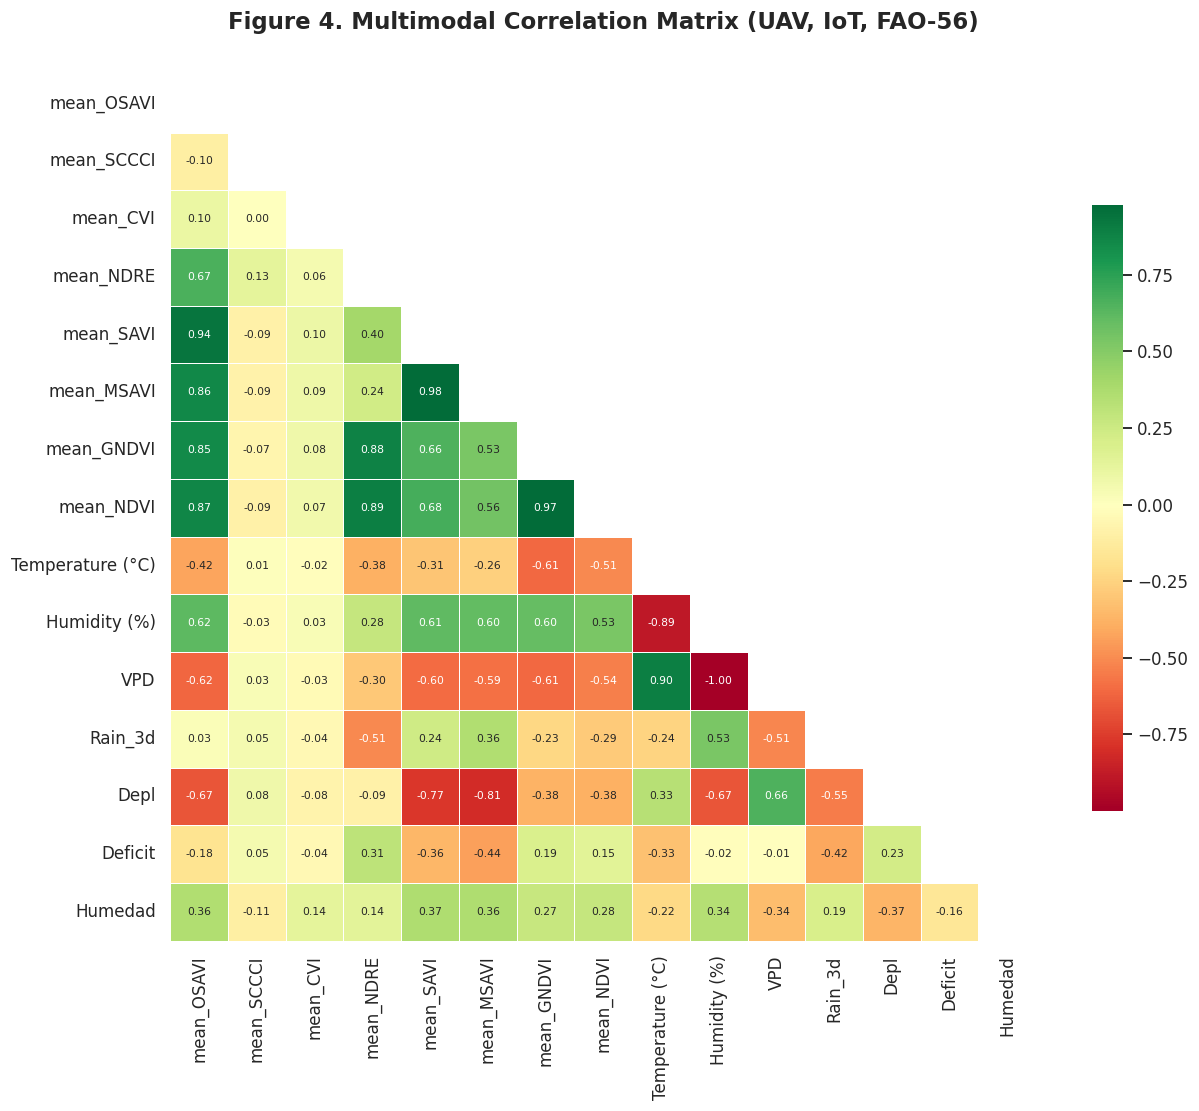

In [ ]:
# Figure 4: multimodal correlation heatmap
plt.figure(figsize=(12, 10))
corr_data = df[features + ['Humedad']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot_kws={"size": 7})
plt.title('Figure 4. Multimodal Correlation Matrix (UAV, IoT, FAO-56)', fontsize=15, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()

## 9. Interpretation, discrepancies, and limitations

**What this run establishes (observed, not assumed):**
- The released PIML-GB code retrains end-to-end on the released fused matrix on a CPU Colab runtime in seconds, and the pipeline (14 features → GBM regressor + GBM traffic-light classifier) runs as published.
- Observed metrics are printed in §7; compare them there against the published R²=0.842 / RMSE=0.0705 and 91.1% accuracy / F1 0.94 / κ 0.91.

**Recorded discrepancies (do not silently resolve them):**
1. **Row count:** the paper describes N=150 (25 units × 6 campaigns, Aug hold-out N=30) but the released CSV has the row count and 5 campaigns printed in §3.
2. **R² 0.842 (paper) vs 0.851 (dataset README)** — the source of the difference is undocumented; the released code pins seeds "to replicate" its figures, but which value reproduces is only established by running it (§7).
3. **Protocol:** the paper reports a spatially blocked stratified 5-fold CV and a temporal (August) hold-out; the released code uses plain random `train_test_split` splits with seeds 13/12. Metrics are therefore not directly comparable to the paper's protocol.
4. **Classifier labels:** the released code's figure labels name Stress/Optimum/Saturation; the CSV encodes `Target` numerically (order shown in §3 outputs) and also carries ` DRY/ NOR/ WET` one-hot columns.

**Not reproduced here (documented omissions):** raw UAV multispectral processing (1.6 GB `IoT_article_images.rar`, MicaSense RedEdge-M SDK, band alignment), the CROPWAT 8.0 desktop FAO-56 water balance (proprietary Windows software; its outputs `Depl`/`Deficit` are precomputed columns in the CSV), and the sensor-log fusion.

*日本語:* 本実行は公開コード・公開データによる最小再現です。論文記載の N=150 と CSV の実行数の不一致、R² 0.842/0.851 の食い違い、および論文の空間ブロック交差検証・8 月ホールドアウトと公開コードの無作為分割の違いは、§3/§7 の実測出力で確認できており、勝手に解決していません。UAV 画像処理と CROPWAT 8.0 の水上収支は未再現です。

## References
- Paper: Plants 15(14):2112 (2026), DOI 10.3390/plants15142112, PMC13414488 (open access).
- Code + data: Mendeley Data v1, `10.17632/9xwdvzf3bf.1`. License field was not exposed by the record API; the paper/investigation describe the repository as CC BY 4.0 — verify before any redistribution.
- FAO-56: Allen et al. (1998), FAO Irrigation & Drainage Paper 56 (via the paper's methodology).